# MigraineGuardian — Model A: Production Lifestyle-Only Migraine Risk Model

**Authoritative Production Training and Validation Notebook**  
**Dataset:** Real Migraine Dataset (11,879 records, 100 users)  
**Algorithm:** Logistic Regression with Balanced Class Weighting (`class_weight="balanced"`, `max_iter=1000`, `random_state=42`)  
**Features:** 11 Total Features (5 Raw Lifestyle Inputs + 6 Domain-Engineered Features)  
**Target:** `migraine_occurrence` (Binary: 0 = No Migraine, 1 = Migraine)  
**Artifact:** `model_a_final_pipeline.pkl`

---
> **Zero Synthetic Data Guarantee:**  
> This model is trained strictly on the real dataset (`migraine_dataset (1).csv`). No synthetic data, fake samples, or artificial augmentations are used.


## 1. Imports


In [1]:
import os
import sys
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay
)

warnings.filterwarnings('ignore')
np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

BASE_DIR = Path.cwd()
if BASE_DIR.name != 'ml-service':
    if (BASE_DIR / 'ml-service').exists():
        BASE_DIR = BASE_DIR / 'ml-service'

if str(BASE_DIR) not in sys.path:
    sys.path.insert(0, str(BASE_DIR))

print(f'Working Directory: {BASE_DIR}')
print(f'NumPy: {np.__version__} | Pandas: {pd.__version__} | Scikit-Learn: {joblib.__version__}')


Working Directory: e:\Migraine_Guardian\ml-service
NumPy: 2.2.6 | Pandas: 2.3.3 | Scikit-Learn: 1.5.3


## 2. Load Real Dataset


In [2]:
data_path = BASE_DIR / 'migraine_dataset (1).csv'
if not data_path.exists():
    data_path = BASE_DIR / 'data' / 'real_migraine_dataset.csv'

df = pd.read_csv(data_path)
print(f'Loaded real dataset from: {data_path.name}')
print(f'Dataset Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
df.head()


Loaded real dataset from: migraine_dataset (1).csv
Dataset Shape: 11,879 rows x 9 columns


,user_id,date,sleep_hours,mood_level,stress_level,hydration_level,screen_time,migraine_occurrence,migraine_severity
0,1,1/15/2024,7.8,3,2,2,4.7,1,1
1,1,1/16/2024,6.6,4,1,2,3.2,1,1
2,1,1/17/2024,8.5,4,2,2,4.7,1,2
3,1,1/18/2024,7.5,3,2,3,3.8,1,3
4,1,1/19/2024,9.0,3,2,1,6.8,1,2


## 3. Dataset Inspection


In [3]:
# Schema and data types
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(by=['user_id', 'date']).reset_index(drop=True)

print('--- Dataset Info ---')
print(df.info())
print()
print('--- Summary Statistics ---')
display(df.describe().T)

# Check missing and duplicate rows
missing_count = df.isnull().sum().sum()
duplicate_rows = df.duplicated().sum()
print(f'Total Missing Values: {missing_count}')
print(f'Total Duplicate Rows: {duplicate_rows}')

# Target distribution
target_counts = df['migraine_occurrence'].value_counts()
target_props = df['migraine_occurrence'].value_counts(normalize=True)
print()
print('Target Distribution (migraine_occurrence):')
print(pd.DataFrame({'Count': target_counts, 'Proportion': target_props}))


--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11879 entries, 0 to 11878
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   user_id              11879 non-null  int64         
 1   date                 11879 non-null  datetime64[ns]
 2   sleep_hours          11879 non-null  float64       
 3   mood_level           11879 non-null  int64         
 4   stress_level         11879 non-null  int64         
 5   hydration_level      11879 non-null  int64         
 6   screen_time          11879 non-null  float64       
 7   migraine_occurrence  11879 non-null  int64         
 8   migraine_severity    11879 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int64(6)
memory usage: 835.4 KB
None

--- Summary Statistics ---


,count,mean,min,25%,50%,75%,max,std
user_id,11879.0,50.388753,1.0,26.0,50.0,75.0,100.0,28.603261
date,11879,2024-04-20 18:43:29.310547968,2023-12-03 00:00:00,2024-03-19 00:00:00,2024-04-20 00:00:00,2024-05-24 00:00:00,2024-08-25 00:00:00,NaN
sleep_hours,11879.0,7.714883,3.0,6.9,7.8,8.5,12.0,1.209977
mood_level,11879.0,3.9388,1.0,3.0,4.0,4.0,5.0,0.768141
stress_level,11879.0,1.39633,1.0,1.0,1.0,2.0,4.0,0.601961
hydration_level,11879.0,2.711087,1.0,2.0,3.0,3.0,5.0,0.929962
screen_time,11879.0,5.723664,1.0,4.7,5.7,6.8,11.4,1.554802
migraine_occurrence,11879.0,0.484889,0.0,0.0,0.0,1.0,1.0,0.499793
migraine_severity,11879.0,0.792996,0.0,0.0,0.0,2.0,3.0,0.920112


Total Missing Values: 0
Total Duplicate Rows: 0

Target Distribution (migraine_occurrence):
                     Count  Proportion
migraine_occurrence                   
0                     6119    0.515111
1                     5760    0.484889


## 4. Feature Selection

Model A is **lifestyle-only** and uses exactly 5 lifestyle inputs from daily check-ins:
- `sleep_hours`
- `mood_level`
- `stress_level`
- `hydration_level`
- `screen_time`

**Excluded from features:**
- `user_id`: Identifier only (used solely for grouping/splitting).
- `date`: Timestamp only (used solely for chronological ordering).
- `migraine_severity`: Post-event outcome information (100% collinear with target; excluded to prevent data leakage).


In [4]:
raw_features = ['sleep_hours', 'mood_level', 'stress_level', 'hydration_level', 'screen_time']
target = 'migraine_occurrence'

print(f'Model Input Features ({len(raw_features)}): {raw_features}')
print(f'Target: {target}')
print('Excluded from features: user_id, date, migraine_severity')


Model Input Features (5): ['sleep_hours', 'mood_level', 'stress_level', 'hydration_level', 'screen_time']
Target: migraine_occurrence
Excluded from features: user_id, date, migraine_severity


## 5. Feature Engineering

We engineer exactly **6 interpretable features** from the 5 lifestyle inputs:
1. `sleep_deviation = abs(sleep_hours - 8.0)`
2. `low_sleep = (sleep_hours < 6.5).astype(int)`
3. `high_screen_time = (screen_time >= 8.0).astype(int)`
4. `low_hydration = (hydration_level <= 2).astype(int)`
5. `stress_mood_interaction = stress_level * (6 - mood_level)`
6. `sleep_screen_interaction = sleep_hours * screen_time`

Total Model A features = **11 features** (5 raw + 6 engineered).


In [5]:
class MigraineFeatureEngineer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        X['sleep_deviation'] = (X['sleep_hours'] - 8.0).abs()
        X['low_sleep'] = (X['sleep_hours'] < 6.5).astype(int)
        X['high_screen_time'] = (X['screen_time'] >= 8.0).astype(int)
        X['low_hydration'] = (X['hydration_level'] <= 2).astype(int)
        X['stress_mood_interaction'] = X['stress_level'] * (6 - X['mood_level'])
        X['sleep_screen_interaction'] = X['sleep_hours'] * X['screen_time']
        return X

sample_transformed = MigraineFeatureEngineer().transform(df[raw_features].head(3))
print(f'Transformed feature count: {sample_transformed.shape[1]}')
print('Transformed columns:', list(sample_transformed.columns))
display(sample_transformed)


Transformed feature count: 11
Transformed columns: ['sleep_hours', 'mood_level', 'stress_level', 'hydration_level', 'screen_time', 'sleep_deviation', 'low_sleep', 'high_screen_time', 'low_hydration', 'stress_mood_interaction', 'sleep_screen_interaction']


,sleep_hours,mood_level,stress_level,hydration_level,screen_time,sleep_deviation,low_sleep,high_screen_time,low_hydration,stress_mood_interaction,sleep_screen_interaction
0,7.8,3,2,2,4.7,0.2,0,0,1,6,36.66
1,6.6,4,1,2,3.2,1.4,0,0,1,2,21.12
2,8.5,4,2,2,4.7,0.5,0,0,1,4,39.95


## 6. Train / Test Split

We perform a user-aware chronological holdout split (80% earlier check-ins per user $\to$ Train, 20% later check-ins per user $\to$ Test) to prevent user leakage and simulate prospective future check-in predictions.


In [6]:
train_indices = []
test_indices = []

for user_id, group in df.groupby('user_id', sort=False):
    n = len(group)
    n_train = int(n * 0.8)
    train_indices.extend(group.index[:n_train])
    test_indices.extend(group.index[n_train:])

train_df = df.iloc[train_indices].copy()
test_df = df.iloc[test_indices].copy()

X_train = train_df[raw_features]
y_train = train_df[target]

X_test = test_df[raw_features]
y_test = test_df[target]

print(f'Training Set: {len(train_df):,} records ({len(train_df)/len(df)*100:.1f}%) | Target Mean: {y_train.mean():.4f}')
print(f'Testing Set:  {len(test_df):,} records ({len(test_df)/len(df)*100:.1f}%) | Target Mean: {y_test.mean():.4f}')


Training Set: 9,465 records (79.7%) | Target Mean: 0.4806
Testing Set:  2,414 records (20.3%) | Target Mean: 0.5017


## 7. Model Pipeline

The complete scikit-learn pipeline:
$$\text{5 Raw Inputs} \xrightarrow{\text{MigraineFeatureEngineer}} \text{11 Features} \xrightarrow{\text{StandardScaler}} \text{LogisticRegression(class\_weight='balanced')}$$


In [7]:
pipeline = Pipeline([
    ('feature_engineering', MigraineFeatureEngineer()),
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])

print('Model A Pipeline:')
print(pipeline)


Model A Pipeline:
Pipeline(steps=[('feature_engineering', MigraineFeatureEngineer()),
                ('scaler', StandardScaler()),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])


## 8. Model Training


In [8]:
# Train on chronological training split
pipeline.fit(X_train, y_train)
print('Model A pipeline successfully fitted on the training split.')


Model A pipeline successfully fitted on the training split.


## 9. Evaluation Metrics


In [9]:
test_preds = pipeline.predict(X_test)
test_probs = pipeline.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, test_preds)
prec = precision_score(y_test, test_preds)
rec = recall_score(y_test, test_preds)
f1 = f1_score(y_test, test_preds)
auc = roc_auc_score(y_test, test_probs)

metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Score': [acc, prec, rec, f1, auc]
})
print('--- Model A Held-Out Validation Metrics ---')
display(metrics_df.style.format({'Score': '{:.4f}'}))


--- Model A Held-Out Validation Metrics ---


,Metric,Score
0,Accuracy,0.6106
1,Precision,0.6126
2,Recall,0.6086
3,F1-Score,0.6106
4,ROC-AUC,0.6406


## 10. Confusion Matrix


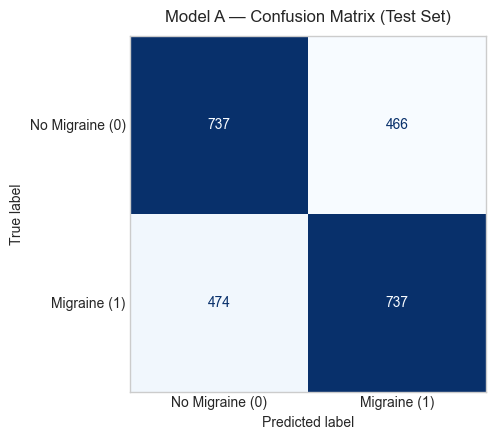

True Negative (TN): 737
False Positive (FP): 466
False Negative (FN): 474
True Positive (TP): 737


In [10]:
cm = confusion_matrix(y_test, test_preds)
fig, ax = plt.subplots(figsize=(5.5, 4.5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Migraine (0)', 'Migraine (1)'])
disp.plot(ax=ax, cmap='Blues', values_format='d', colorbar=False)
ax.set_title('Model A — Confusion Matrix (Test Set)', fontsize=12, pad=10)
ax.grid(False)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True Negative (TN): {tn}')
print(f'False Positive (FP): {fp}')
print(f'False Negative (FN): {fn}')
print(f'True Positive (TP): {tp}')


## 11. Receiver Operating Characteristic (ROC) Curve


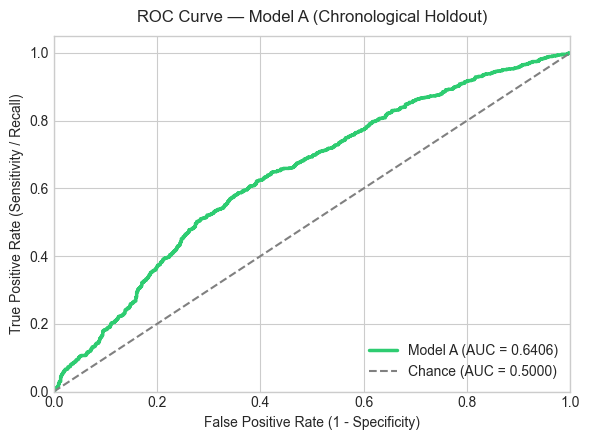

In [11]:
fpr, tpr, _ = roc_curve(y_test, test_probs)

plt.figure(figsize=(6, 4.5))
plt.plot(fpr, tpr, color='#2ECC71', lw=2.5, label=f'Model A (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Chance (AUC = 0.5000)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity / Recall)')
plt.title('ROC Curve — Model A (Chronological Holdout)', fontsize=12, pad=10)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


## 12. Final Training on All Real Data


In [12]:
final_model = Pipeline([
    ('feature_engineering', MigraineFeatureEngineer()),
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])

# Train on complete real dataset (11,879 records)
final_model.fit(df[raw_features], df[target])
print(f'Final Model A successfully trained on all {len(df):,} real dataset records.')


Final Model A successfully trained on all 11,879 real dataset records.


## 13. Save Model Artifact (`model_a_final_pipeline.pkl`)


In [13]:
artifact_path = BASE_DIR / 'app' / 'models' / 'model_a_final_pipeline.pkl'
artifact_path.parent.mkdir(parents=True, exist_ok=True)

joblib.dump(final_model, artifact_path)

# Save compatibility mirror
compat_path = BASE_DIR / 'app' / 'models' / 'migraine_pipeline.pkl'
joblib.dump(final_model, compat_path)

print(f'Saved primary artifact: {artifact_path} ({os.path.getsize(artifact_path):,} bytes)')
print(f'Saved compatibility artifact: {compat_path} ({os.path.getsize(compat_path):,} bytes)')


Saved primary artifact: e:\Migraine_Guardian\ml-service\app\models\model_a_final_pipeline.pkl (2,209 bytes)
Saved compatibility artifact: e:\Migraine_Guardian\ml-service\app\models\migraine_pipeline.pkl (2,209 bytes)


## 14. Reload Model Artifact


In [14]:
loaded_model = joblib.load(artifact_path)
print(f'Successfully reloaded model from: {artifact_path.name}')
print('Pipeline Steps:', [name for name, _ in loaded_model.steps])
assert hasattr(loaded_model, 'predict'), 'Loaded model missing predict!'
assert hasattr(loaded_model, 'predict_proba'), 'Loaded model missing predict_proba!'
print('Reload Verification: PASSED')


Successfully reloaded model from: model_a_final_pipeline.pkl
Pipeline Steps: ['feature_engineering', 'scaler', 'model']
Reload Verification: PASSED


## 15. Inference Test

We perform an inference test using a valid 5-feature lifestyle check-in payload from the real dataset. The pipeline internally performs feature engineering, scaling, and probability estimation.


In [15]:
test_input = pd.DataFrame([{
    'sleep_hours': 7.0,
    'mood_level': 4,
    'stress_level': 2,
    'hydration_level': 3,
    'screen_time': 6.0
}])

pred_class = loaded_model.predict(test_input)[0]
pred_proba = loaded_model.predict_proba(test_input)[0]
risk_score = round(pred_proba[1] * 100, 2)

print('--- Inference Test Results ---')
print('Inputs:')
for k, v in test_input.iloc[0].items():
    print(f'  {k}: {v}')
print()
print(f'Predicted Class (0=No Migraine, 1=Migraine): {pred_class}')
print(f'Probability No Migraine (Class 0): {pred_proba[0]:.4f}')
print(f'Probability Migraine (Class 1):    {pred_proba[1]:.4f}')
print(f'Calculated Migraine Risk Score:    {risk_score}%')
print('Inference Test: PASSED')


--- Inference Test Results ---
Inputs:
  sleep_hours: 7.0
  mood_level: 4.0
  stress_level: 2.0
  hydration_level: 3.0
  screen_time: 6.0

Predicted Class (0=No Migraine, 1=Migraine): 0
Probability No Migraine (Class 0): 0.5533
Probability Migraine (Class 1):    0.4467
Calculated Migraine Risk Score:    44.67%
Inference Test: PASSED
